14:54:01 - cmdstanpy - INFO - Chain [1] start processing
14:54:02 - cmdstanpy - INFO - Chain [1] done processing


Baseline Model Historical MAPE: 56.89%


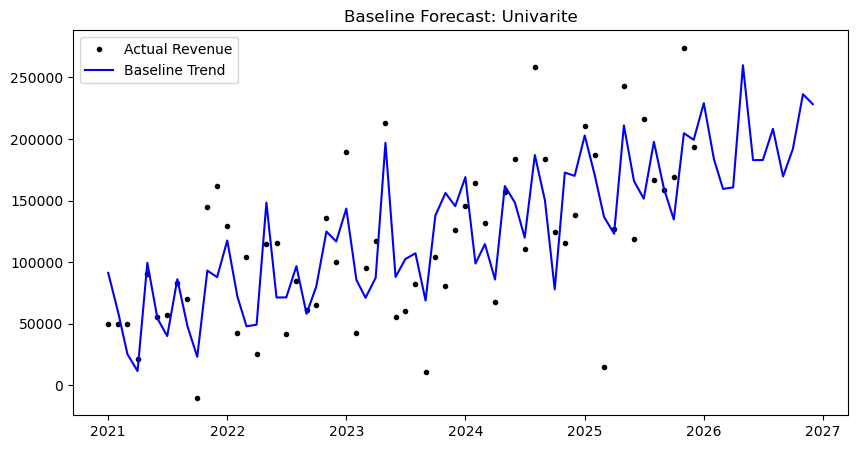

14:54:04 - cmdstanpy - INFO - Chain [1] start processing
14:54:04 - cmdstanpy - INFO - Chain [1] done processing


Driver-Based Model Historical MAPE: 57.02%


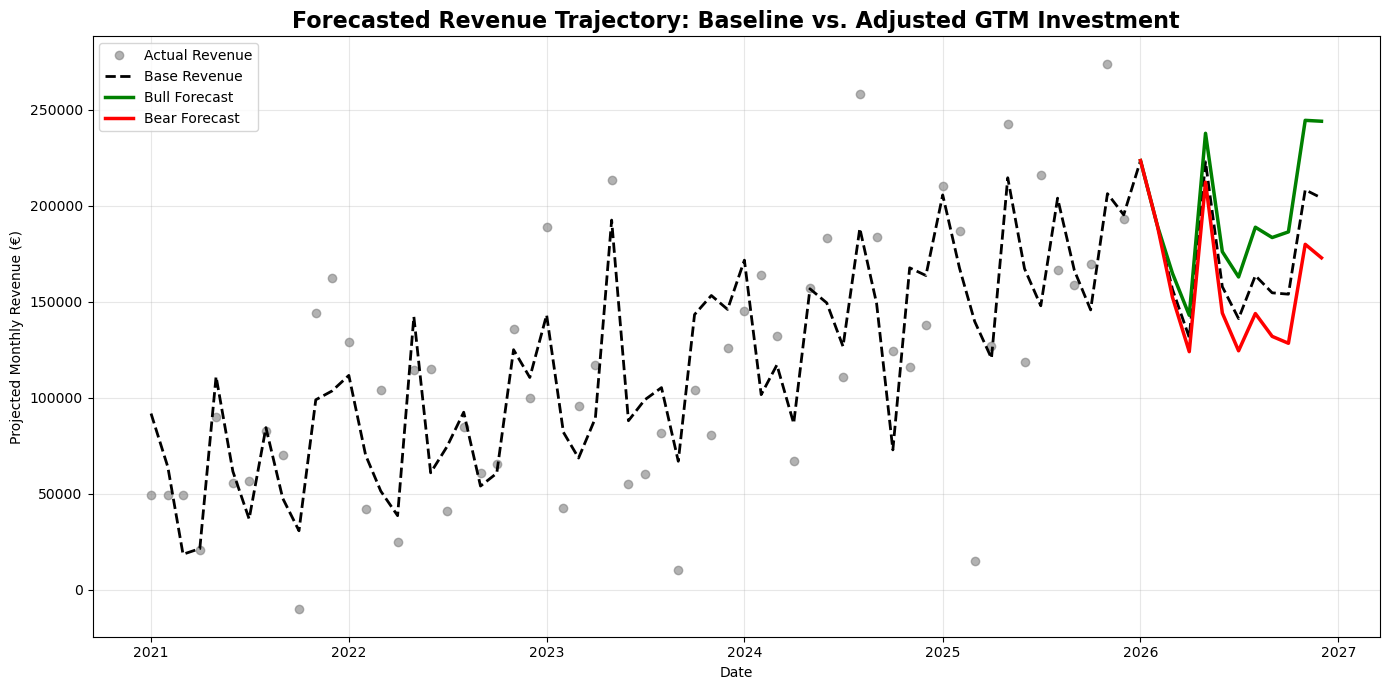

In [4]:
import pandas as pd
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error

df = pd.read_csv('revops_synthetic_dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])
last_historical_date = df['Date'].max()


df_base = df[['Date', 'Revenue']].rename(columns={'Date': 'ds', 'Revenue': 'y'})

m_base = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m_base.fit(df_base)

# Predict past & future for baseline
future_base_only = m_base.make_future_dataframe(periods=12, freq='MS')
forecast_base_only = m_base.predict(future_base_only)

# Calculate Baseline Accuracy
baseline_predictions = forecast_base_only['yhat'][:len(df)]
baseline_mape = mean_absolute_percentage_error(df['Revenue'], baseline_predictions)
print(f"Baseline Model Historical MAPE: {baseline_mape:.2%}")

# Plot Baseline
plt.figure(figsize=(10, 5))
plt.plot(df['Date'], df['Revenue'], 'k.', label='Actual Revenue')
plt.plot(forecast_base_only['ds'], forecast_base_only['yhat'], color='blue', label='Baseline Trend')
plt.title('Baseline Forecast: Univarite')
plt.legend()

plt.show() 

df_drivers = df[['Date', 'Revenue', 'Marketing_Spend_Lag_2', 'Promo_Days_Lag_1']].copy()
df_drivers = df_drivers.rename(columns={'Date': 'ds', 'Revenue': 'y'})

m_drivers = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m_drivers.add_regressor('Marketing_Spend_Lag_2')
m_drivers.add_regressor('Promo_Days_Lag_1')
m_drivers.fit(df_drivers)

# Predict past & future for Driver model to get its MAPE
future_drivers_eval = future_base_only.merge(df[['Date', 'Marketing_Spend_Lag_2', 'Promo_Days_Lag_1']], 
                                             left_on='ds', right_on='Date', how='left').drop(columns=['Date'])

future_drivers_eval.ffill(inplace=True) 

forecast_drivers_eval = m_drivers.predict(future_drivers_eval)

driver_predictions = forecast_drivers_eval['yhat'][:len(df)]
driver_mape = mean_absolute_percentage_error(df['Revenue'], driver_predictions)
print(f"Driver-Based Model Historical MAPE: {driver_mape:.2%}")


# Re-build future base with last known values
future_base = future_base_only.merge(df[['Date', 'Marketing_Spend_Lag_2', 'Promo_Days_Lag_1']], 
                                 left_on='ds', right_on='Date', how='left').drop(columns=['Date'])

last_spend = df['Marketing_Spend_Lag_2'].iloc[-1]
last_promo = df['Promo_Days_Lag_1'].iloc[-1]

future_base['Marketing_Spend_Lag_2'].fillna(last_spend, inplace=True)
future_base['Promo_Days_Lag_1'].fillna(last_promo, inplace=True)

future_bull = future_base.copy()
future_bear = future_base.copy()

# Apply Compounding Budget starting Month 3
growth_rates = [(1.02 ** i) for i in range(10)] 
decay_rates = [(0.98 ** i) for i in range(10)]

future_bull.loc[future_bull.index[-10:], 'Marketing_Spend_Lag_2'] = last_spend * np.array(growth_rates)
future_bear.loc[future_bear.index[-10:], 'Marketing_Spend_Lag_2'] = last_spend * np.array(decay_rates)

# Apply Promo Days
future_bull.loc[future_bull.index[-10:], 'Promo_Days_Lag_1'] = last_promo + 2
future_bear.loc[future_bear.index[-10:], 'Promo_Days_Lag_1'] = max(0, last_promo - 1)

forecast_base = m_drivers.predict(future_base)
forecast_bull = m_drivers.predict(future_bull)
forecast_bear = m_drivers.predict(future_bear)

plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Revenue'], marker='o', linestyle='', color='grey', alpha=0.6, label='Actual Revenue')
plt.plot(forecast_base['ds'], forecast_base['yhat'], color='black', linewidth=2, linestyle='--', label='Base Revenue')

future_dates = forecast_base['ds'].iloc[-12:]
plt.plot(future_dates, forecast_bull['yhat'].iloc[-12:], color='green', linewidth=2.5, label='Bull Forecast')
plt.plot(future_dates, forecast_bear['yhat'].iloc[-12:], color='red', linewidth=2.5, label='Bear Forecast')

plt.title('Forecasted Revenue Trajectory: Baseline vs. Adjusted GTM Investment', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Projected Monthly Revenue (€)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()